## 6. SMF comparison: MACH vs. TNG300

This notebook compares the stacked stellar mass function (SMF) of massive MACH clusters to the TNG300 simulation.

- **Cells 0–2**: load catalogs, set cosmology, and precompute absolute magnitudes for MACH galaxies.
- **Cell 3**: build stacked galaxy SMFs from massive TNG300 haloes at snapshot 93.
- **Cell 4**: plot the TNG300 stacked SMF with sampling uncertainties.

Use this notebook mainly as a bridge between the observed MACH SMFs and the simulated cluster SMFs at similar redshift.

In [1]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.table import Table
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

import matplotlib.pyplot as plt

# Matplotlib configuration
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,           
    'ytick.right': True,         
    'xtick.minor.visible': True, 
    'ytick.minor.visible': True, 
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Pandas configuration
pd.set_option('display.max_columns', None)

# Paths configuration
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']
MAINPATH =  "/Users/jonginpark/sohnix/Research_Archive/2026/Park2026b-MACH-SMF"

%config InlineBackend.figure_format = 'retina'

In [2]:
# Load MACH master catalog
mach_path = f"{MAINPATH}/DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv"
mach_data = pd.read_csv(mach_path)

# Correct cmodel magnitudes for extinction
for band in ("g", "r"):
    mach_data[f"cmodelMag_{band}_0"] = (
        mach_data[f"cmodelMag_{band}"] - mach_data[f"extinction_{band}"]
    )

# Load HeCS VAC catalog
hecs_vac_path = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"
hecs_vac_data = pd.read_csv(hecs_vac_path)

df = mach_data.copy()

# Construct Mock_z: use Z_TOT_Z, but if Z_TOT_Z == -99, use cluster mean z from hecs_vac_data (by CLID)
df["Mock_z"] = df["Z_TOT_Z"]

# Find rows with Z_TOT_Z == -99
mask_noz = (df["Z_TOT_Z"] == -99)

# For those rows, replace with matching cluster z from hecs_vac_data
if "CLID" in df.columns and "CLID" in hecs_vac_data.columns:
    # Construct cluster z dictionary from hecs_vac_data
    clid_to_z = hecs_vac_data.set_index("CLID")["Z"].to_dict()
    # Fill Mock_z for those without z
    df.loc[mask_noz, "Mock_z"] = df.loc[mask_noz, "CLID"].map(clid_to_z)

# Compute absolute r-band magnitude using Mock_z
lum_dist_pc = cosmo.luminosity_distance(df["Mock_z"]).to("pc").value
df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_72054/881514430.py:32: RuntimeWarning: divide by zero encountered in log10
  df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_72054/881514430.py:32: RuntimeWarning: invalid value encountered in log10
  df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)


In [3]:
import numpy as np

# Load MACH stacked SMF results within R200 from the .npz file
npz_path = './SMF_results/MACH_total_results_R200.npz'
data_mach_total = np.load(npz_path, allow_pickle=True)

# Example: unpack commonly used arrays (optional)
mean_all        = data_mach_total['mean_all']
mean_quenched   = data_mach_total['mean_quenched']
mean_sf         = data_mach_total['mean_sf']
original_counts = data_mach_total['original_counts']
bin_centers     = data_mach_total['bin_centers']
SMF_complimit   = float(data_mach_total['complim'])

### TNG300 snapshot 93: build stacked cluster SMF

This cell constructs an average SMF for the most massive TNG300 clusters at snapshot 93:

- Select haloes with `M200c > 5 × 10^{14} M_\odot` from the halo catalogue.
- For each halo, load its member galaxies, select those within `R_{200}` in comoving Mpc, and bin their stellar masses in log\(M_*\).
- Convert counts to \(\phi(M)\) per dex by dividing by the bin width.
- Stack all haloes: compute the mean SMF and its standard error across the halo sample.

The resulting arrays `bin_centers`, `mean_hist`, `stderr`, and `valid` are used for the comparison plot in the next cell.

In [4]:
# ---- Data Calculation Part ----
import pandas as pd
import numpy as np

cosmo_h = 0.6774

# Load halo info for snapshot 93
haloinfo_93 = pd.read_csv(f'{MAINPATH}/DATA/TNG300/TNG300_output_snapNum_93/Massive_Haloinfo_SnapNum93.csv')
massive_haloinfo_93 = haloinfo_93[haloinfo_93['Group_M_Crit200']*1e10/cosmo_h > 5e14]

# Binning setup
bin_min, bin_max, bin_width = 7, 13, 0.25
bins = np.arange(bin_min, bin_max + bin_width, bin_width)
bin_centers = bins[:-1] + bin_width / 2

halo_ids = massive_haloinfo_93["HaloIndex"].values
r_key = "Group_R_Crit200"
hist_list = []

for hid in halo_ids:
    fpath = f'{MAINPATH}/DATA/TNG300/TNG300_output_snapNum_93/HALOCAT/halo{hid:08d}_result.csv'
    try:
        df = pd.read_csv(fpath)
    except FileNotFoundError:
        print(f"Missing {fpath}")
        continue

    R_kpc = massive_haloinfo_93.loc[massive_haloinfo_93["HaloIndex"] == hid, r_key].iloc[0]
    R_cmpc = R_kpc * 1e-3 / cosmo_h
    R_sel = R_cmpc

    sel = df[df["Distance (cMpc)"] < R_sel]
    if sel.empty:
        continue

    logm = np.log10(sel["StellarMass (Msol)"])
    counts, _ = np.histogram(logm, bins=bins)
    hist_list.append(counts / bin_width)

# Collect results
if hist_list:
    H = np.vstack(hist_list)
    mean_hist = H.mean(axis=0)
    stderr = H.std(axis=0, ddof=1) / np.sqrt(H.shape[0])
    valid = mean_hist > 0
else:
    print("No valid histograms for snapshot 93")
    mean_hist = np.zeros_like(bin_centers)
    stderr = np.zeros_like(bin_centers)
    valid = np.zeros_like(bin_centers, dtype=bool)

/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inp

### Plot TNG300 stacked SMF (snapshot 93)

This cell visualizes the stacked TNG300 SMF computed above:

- Plot the mean SMF with logarithmic y–axis, using error bars from the halo-to-halo scatter (standard error of the mean).
- Add a shaded band corresponding to \(\pm 1\sigma\) uncertainty around the mean.
- Use the same x–range as the MACH SMF (\(9.5 \lesssim \log M_* \lesssim 13.4\)) so the plot can be compared directly to the observations.

You can later overlay the MACH stacked SMF on this same axis to make a direct visual comparison.

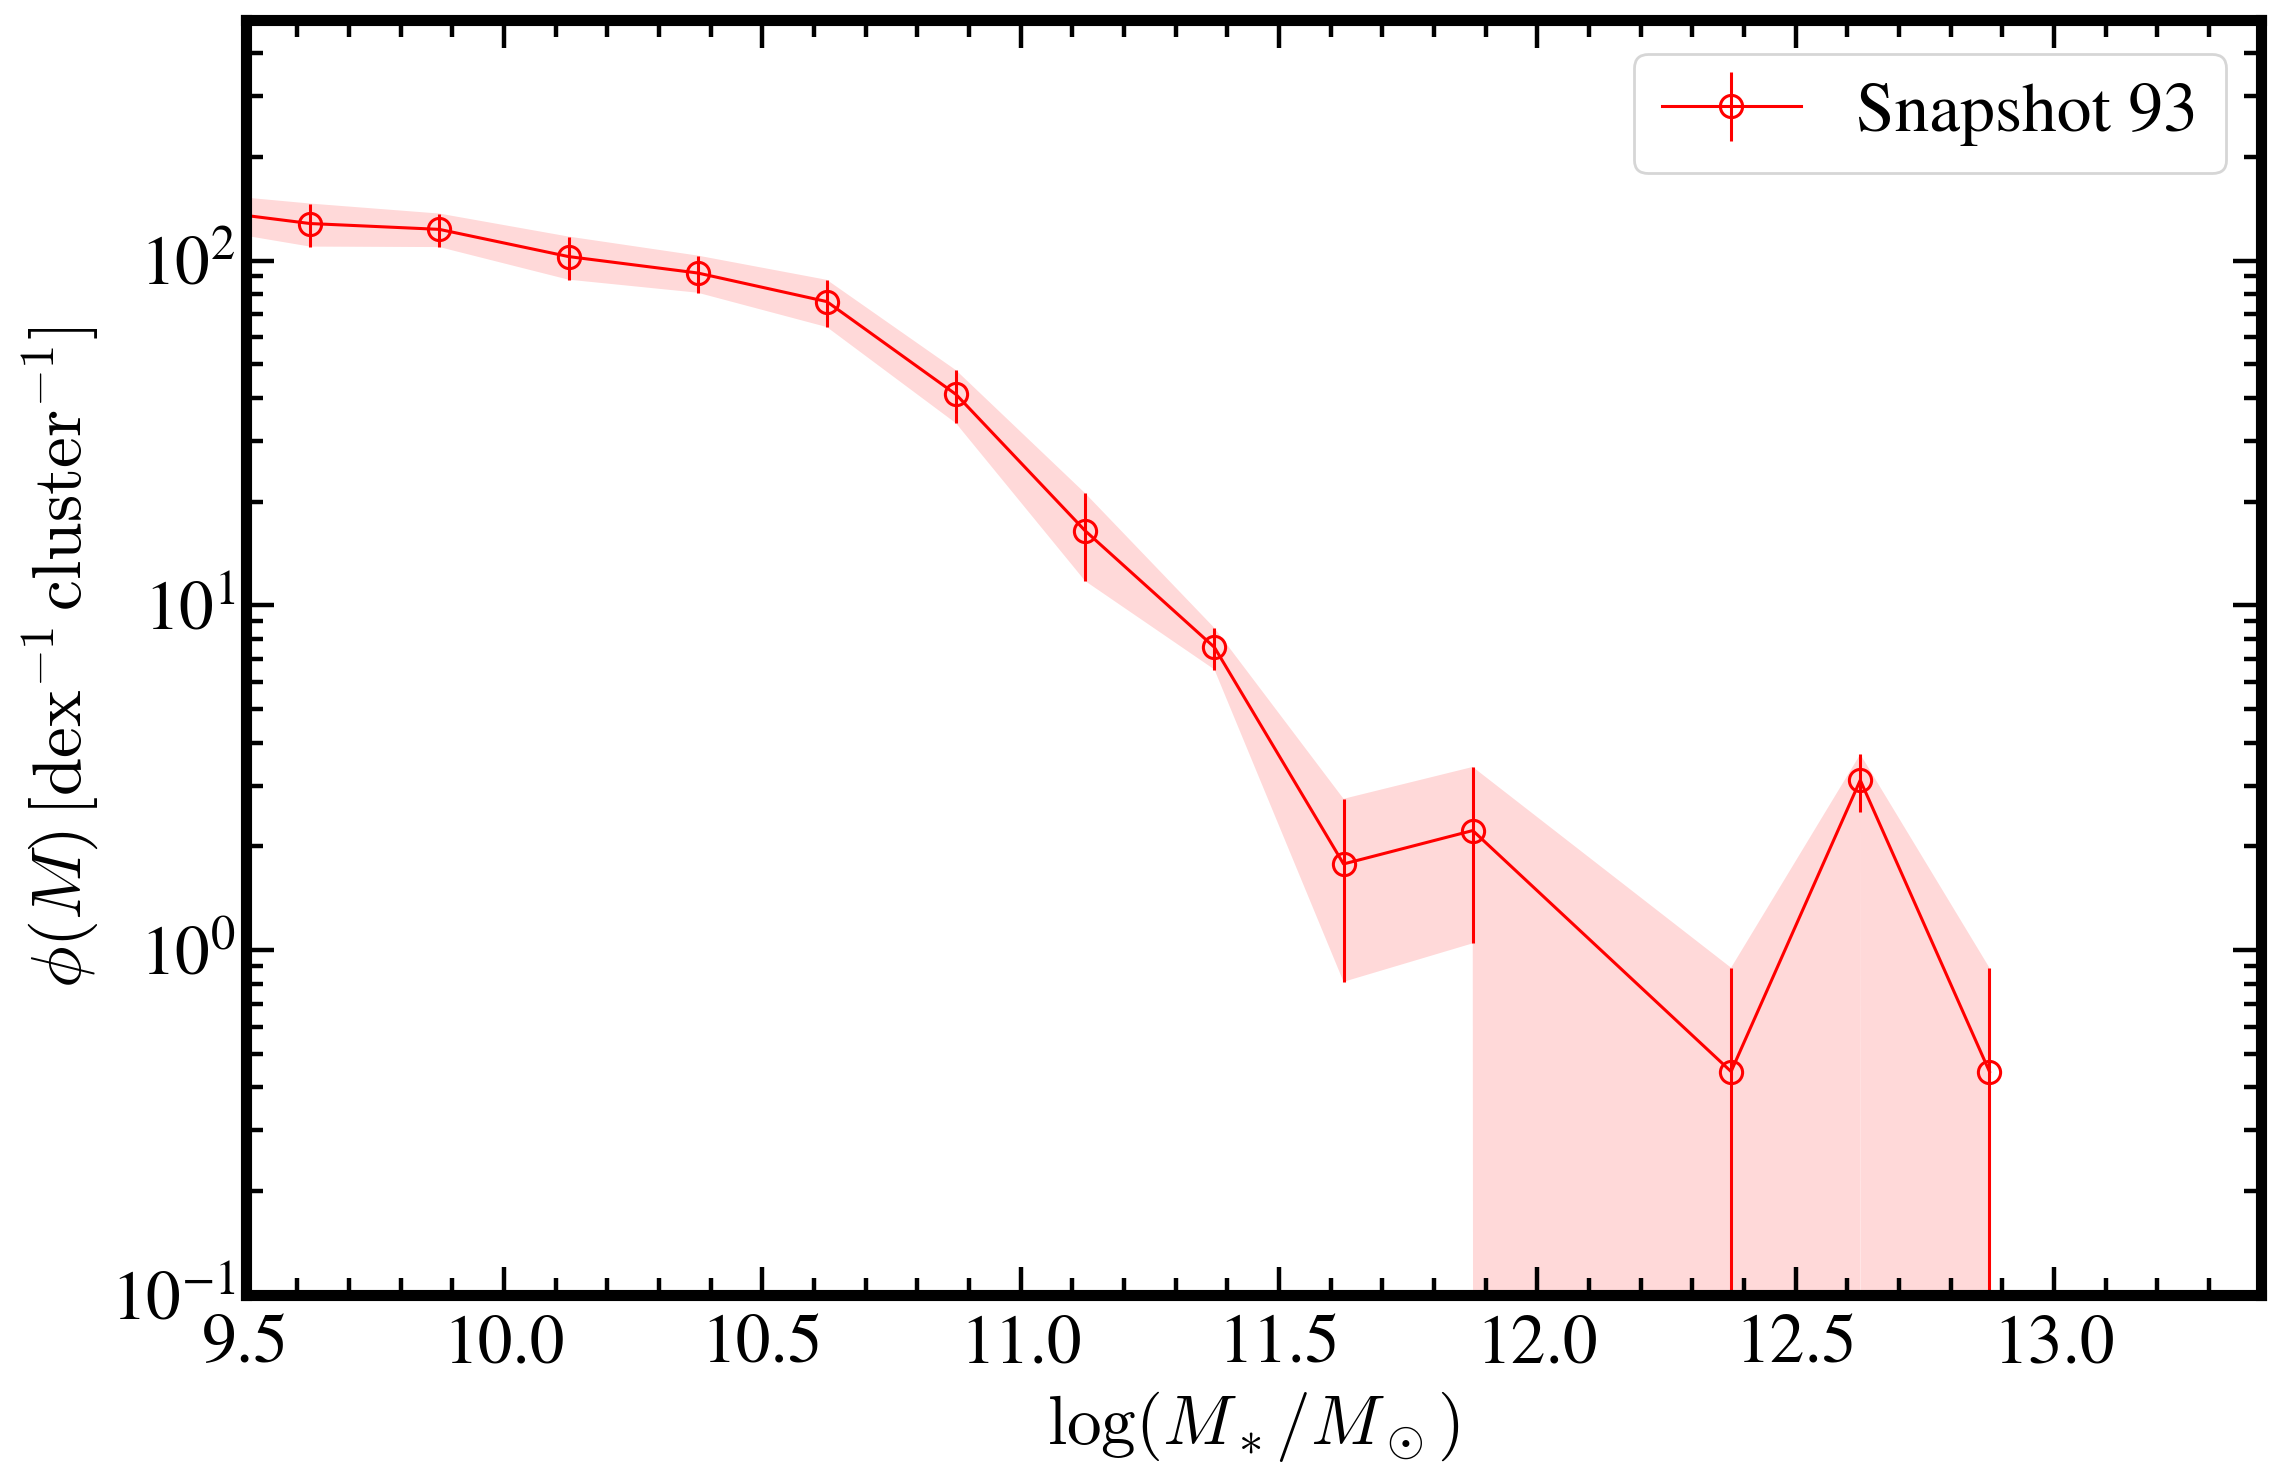

In [5]:
# ---- Plotting Part ----
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

if np.any(valid):
    ax.fill_between(bin_centers[valid],
                    mean_hist[valid] - stderr[valid],
                    mean_hist[valid] + stderr[valid],
                    color='red', alpha=0.15, linewidth=0)
    ax.errorbar(bin_centers[valid], mean_hist[valid], yerr=stderr[valid],
                fmt='o-', color='red',
                markerfacecolor='none', markeredgecolor='red',
                markeredgewidth=1.1, markersize=8, capsize=0, linewidth=1.1,
                label='Snapshot 93')

ax.set_xlim(9.5, 13.4)
ax.set_ylim(0.1, 500)
ax.set_yscale('log')
ax.set_xlabel(r'$\log(M_*/M_\odot)$')
ax.set_ylabel(r'$\phi(M)\,[\mathrm{dex}^{-1}\,\mathrm{cluster}^{-1}]$')
ax.legend()
plt.tight_layout()
plt.show()


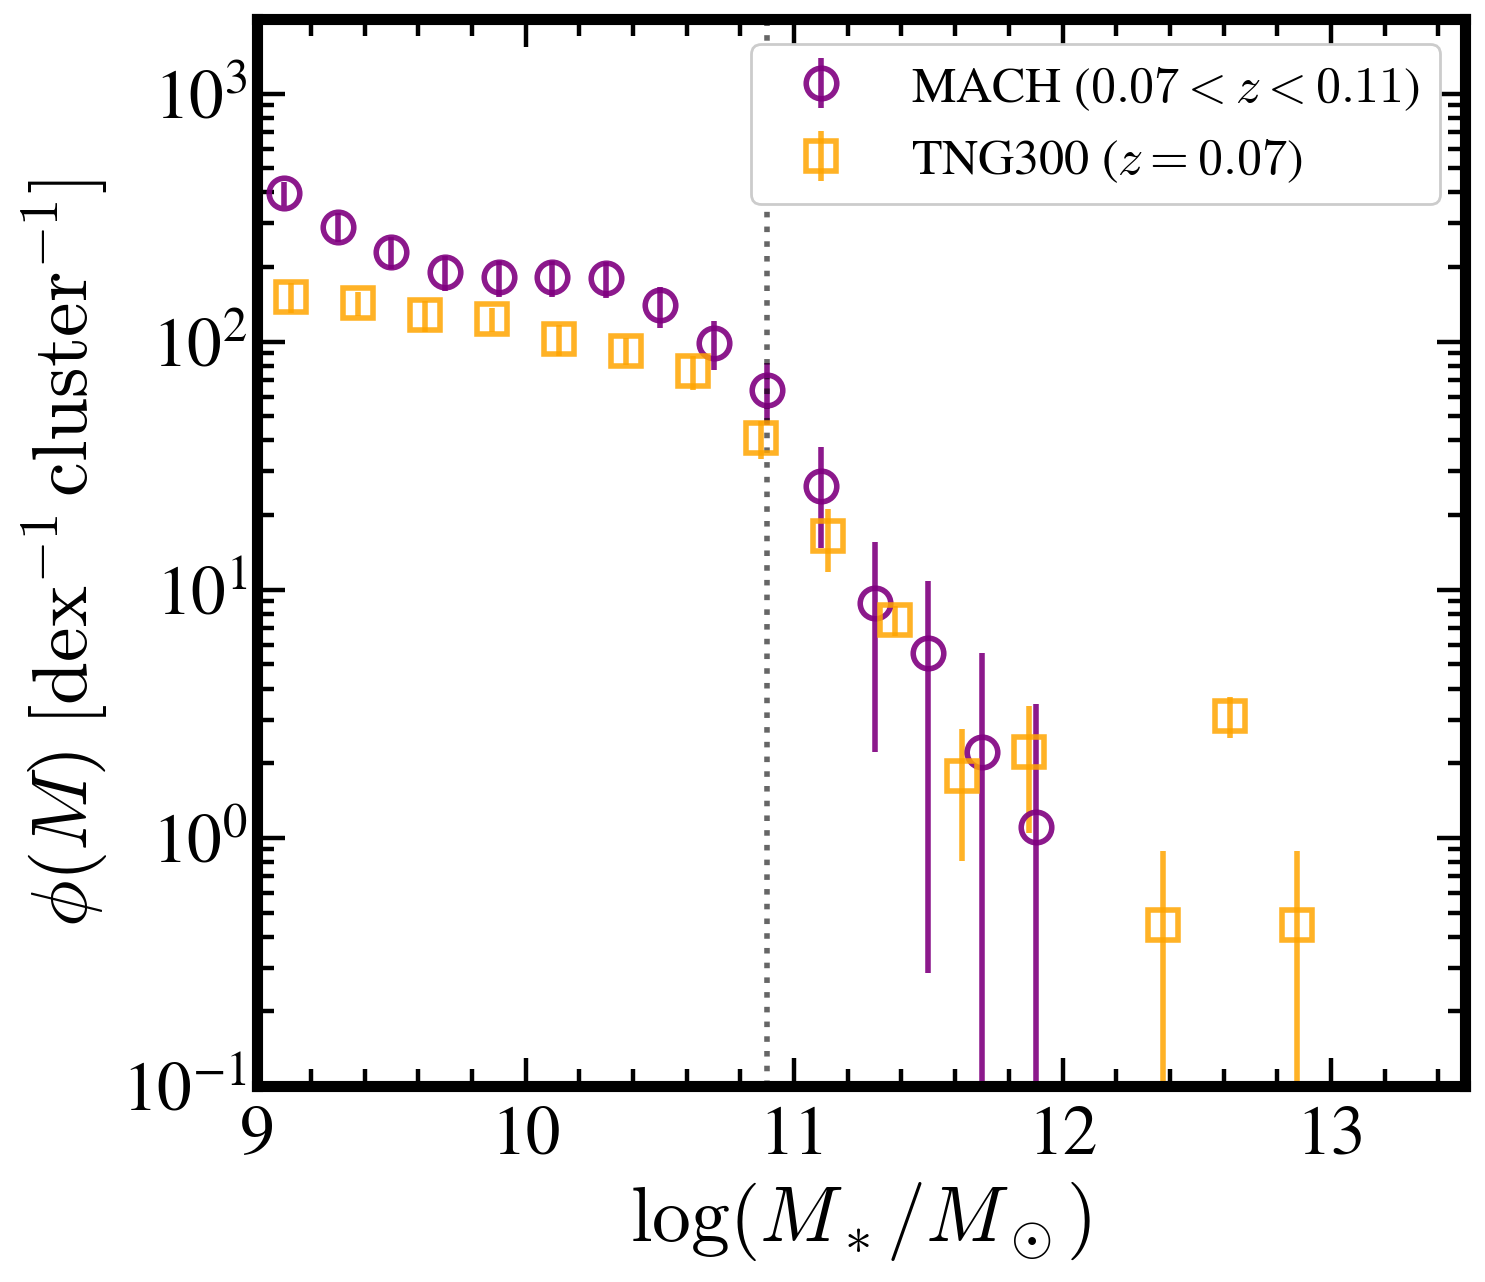

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# NOTE: assumes the following are already in memory:
#   data_mach_total  – loaded from MACH_total_results_R200.npz
#   mean_hist        – TNG snap 93 mean Φ per bin  (from TNG calc cell)
#   stderr           – TNG snap 93 standard error  (from TNG calc cell)
#   bin_centers      – TNG bin centers              (from TNG calc cell)
#   valid            – TNG valid-bin mask            (from TNG calc cell)
# =============================================================

# --- Reference mass for normalisation ---
# The TNG curve is rescaled so it passes through the MACH value at ref_mass.
ref_mass  = 10.90
obs_bw    = 0.2     # bin_width used in the MACH pipeline

# =============================================================
# MACH observational SMF  (snap 93: z ~ 0.07–0.11)
# =============================================================
obs_x     = data_mach_total['bin_centers']
obs_y     = data_mach_total['mean_all'] / obs_bw     # convert counts → Φ [dex⁻¹ cluster⁻¹]
obs_yerr  = np.sqrt(data_mach_total['mean_all']) / obs_bw   # simple Poisson error

# =============================================================
# TNG300 snap 93  (z = 0.07)
# Already computed in the TNG calculation cell as mean_hist / stderr / valid
# =============================================================
tng_x  = bin_centers[valid]
tng_y  = mean_hist[valid]
tng_lo = stderr[valid]
tng_hi = stderr[valid]

# =============================================================
# Normalise TNG to match MACH at ref_mass
#   scale = Φ_obs(ref_mass) / Φ_TNG(ref_mass)
# =============================================================
idx_obs = np.argmin(np.abs(obs_x - ref_mass))
idx_tng = np.argmin(np.abs(tng_x - ref_mass))
scale   = obs_y[idx_obs] / tng_y[idx_tng]

tng_y_scaled  = tng_y  * scale
tng_lo_scaled = tng_lo * scale
tng_hi_scaled = tng_hi * scale

# =============================================================
# Plot
# =============================================================
fig, ax = plt.subplots(figsize=(8, 7))

# --- MACH observed SMF ---
ax.errorbar(
    obs_x, obs_y,
    yerr=[obs_yerr, obs_yerr],
    fmt='o', ms=11, lw=2,
    color='purple', markerfacecolor='none',
    markeredgecolor='purple', markeredgewidth=2,
    ecolor='purple', capsize=0, alpha=0.9,
    label=r'MACH ($0.07 < z < 0.11$)'
)

# --- TNG300 raw (unscaled) ---
ax.errorbar(
    tng_x, tng_y,
    yerr=[tng_lo, tng_hi],
    fmt='s', ms=11, lw=2,
    color='orange', markerfacecolor='none',
    markeredgecolor='orange', markeredgewidth=2,
    ecolor='orange', capsize=0, alpha=0.85,
    label=r'TNG300 ($z = 0.07$)'
)

# --- TNG300 normalised ---
# ax.errorbar(
#     tng_x, tng_y_scaled,
#     yerr=[tng_lo_scaled, tng_hi_scaled],
#     fmt='^', ms=11, lw=2,
#     color='tab:green', markerfacecolor='none',
#     markeredgecolor='tab:green', markeredgewidth=2,
#     ecolor='tab:green', capsize=0, alpha=0.85,
#     label=r'TNG300 ($z = 0.07$, normalised)'
# )

# --- Reference mass vertical line ---
ax.axvline(ref_mass, color='black', linestyle=':', lw=2, alpha=0.6)

# --- Axes formatting ---
ax.set_yscale('log')
ax.set_xlim(9, 13.5)
ax.set_ylim(0.1, 2000)
ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=28)
ax.set_ylabel(r'$\phi(M)\;[\mathrm{dex}^{-1}\,\mathrm{cluster}^{-1}]$', fontsize=28)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.legend(loc='upper right', fontsize=18, frameon=True, framealpha=1)

plt.tight_layout()
plt.savefig(f'{MAINPATH}/FIGURE/IMAGES/Figure17.pdf', bbox_inches='tight')
plt.show()